In [ ]:
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import time

In [ ]:
# ==========================================
# 1. Data Loading & Preprocessing
# ==========================================
print("Loading Data...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values (0 to 1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images for Logistic Regression and Decision Tree
# (60000, 28, 28) -> (60000, 784)
x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))

results = {}

Loading Data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train.shape)

(60000, 28, 28)


In [ ]:
print(x_train_flat.shape)

(60000, 784)


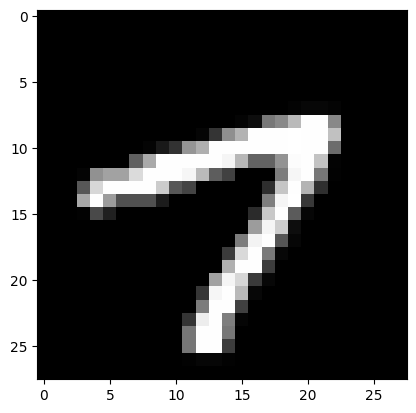

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(x_train[101] , cmap = 'grey')

plt.show()

# 2. Decision Tree (The Baseline)

In [ ]:
print("\n--- Training Decision Tree ---")
model_dt = DecisionTreeClassifier()

model_dt.fit(x_train_flat , y_train)

ytrainPred = model_dt.predict(x_train_flat)
ytestPred = model_dt.predict(x_test_flat)

from sklearn.metrics import accuracy_score
print("Accuracy training data-" ,
      accuracy_score(y_train,ytrainPred))

print("Accuracy training data-" ,
      accuracy_score(y_test,ytestPred))


--- Training Decision Tree ---
Accuracy training data- 1.0
Accuracy training data- 0.8782


# 2. Logistic Regression

In [ ]:
print("\n--- Training Logistic Regression ---")
model_log = LogisticRegression()

model_log.fit(x_train_flat , y_train)

ytrainPred = model_log.predict(x_train_flat)
ytestPred = model_log.predict(x_test_flat)

from sklearn.metrics import accuracy_score
print("Accuracy training data-" ,
      accuracy_score(y_train,ytrainPred))

print("Accuracy training data-" ,
      accuracy_score(y_test,ytestPred))


--- Training Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy training data- 0.9346166666666667
Accuracy training data- 0.9256


# 3. Multi layer perceptron

In [ ]:
from keras import models, layers
from keras.layers import Input

model = models.Sequential([
    Input(shape=(784,)), # Explicitly define input shape using Input layer
    layers.Dense(64, activation='relu'), # Added relu activation
    layers.Dense(32, activation='relu'), # Added relu activation
    layers.Dense(10, activation='softmax') # Output layer with softmax for multi-class classification
])

In [ ]:
from keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001) ,
              loss = 'categorical_crossentropy' , # Use categorical_crossentropy for one-hot encoded labels
              metrics = ['accuracy']) # 'accuracy' is more appropriate for classification

In [ ]:
from tensorflow.keras.utils import to_categorical
ytrain_encoded = to_categorical(y_train)
ytest_encoded = to_categorical(y_test)

In [ ]:
from tensorflow.keras.utils import to_categorical
ytrain_encoded = to_categorical(y_train)
ytest_encoded = to_categorical(y_test)

In [ ]:
print("\n--- Training Multi-layer Perceptron ---")
model.fit(x_train_flat , ytrain_encoded , epochs = 10,
          validation_data= (x_test_flat , ytest_encoded))

print("\n--- Evaluating Multi-layer Perceptron ---")
loss, accuracy = model.evaluate(x_test_flat, ytest_encoded)
results['Multi-layer Perceptron'] = accuracy
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


--- Training Multi-layer Perceptron ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9215 - loss: 0.2738 - val_accuracy: 0.9578 - val_loss: 0.1358
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9628 - loss: 0.1272 - val_accuracy: 0.9615 - val_loss: 0.1248
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9717 - loss: 0.0905 - val_accuracy: 0.9712 - val_loss: 0.0963
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9796 - loss: 0.0660 - val_accuracy: 0.9710 - val_loss: 0.0897
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9819 - loss: 0.0552 - val_accuracy: 0.9708 - val_loss: 0.0972
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9854 - loss: 0.0435 - val_accuracy: 0.9729 - val_loss: 0.0940
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9871 - loss: 0.0398 - val_accuracy: 0.9739 - val_loss: 0.0955
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/